# Running Differential Expression for WSP RNA-seq

In [3]:
library(data.table)
library(stringr)
# plotting
library(ggplot2)
library(cowplot)
# DE analysis
#library(limma)
library(edgeR)
library(DESeq2)
library(UpSetR)
library(gridExtra)
library(clusterProfiler)
library(org.Hs.eg.db)

In [ ]:
# save the results and TFEA input
results_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/results/DESeq2/"

## 1. Get Counts

In [7]:
# read in preliminary 5ptrunc counts
# the 
count_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/WSP_RNA_B2B/counts/"
genes_file=paste0(count_dir, "WSP_RNA_B2B_str_gtf_genes.txt")
gene_counts <- fread(genes_file)
gene_counts[1:2,]

# get easier names
colnames(gene_counts) <- c("Geneid", "Chr", "Start", "End", "Strand", "Length", 
                           "Veh_1", "Veh_2", "Veh_3", "Veh_4", 
						   "WSP2h_1", "WSP2h_2", "WSP2h_3", "WSP2h_4",
						   "WSP4h_1", "WSP4h_2", "WSP4h_3", "WSP4h_4")

length(unique(gene_counts$Geneid))

# only keep nonputative genes to maintain consistency with PRO-seq analyses
nonput <- fread("/Users/hopekirby/Desktop/TF_Enh_Linking/Final_Project_Repos/Bidir_Counting_Analysis/assets/hg38_refseq_diff53prime_5ptrunc_counting.bed")
nonput$Gene <- str_split_fixed(nonput$V4, ":", 2)[,1]
nrow(nonput)
length(unique(nonput$Gene))
nonput[1:2,]

setdiff(gene_counts$Geneid, nonput$Gene)[1:3]
gene_counts <- gene_counts[gene_counts$Geneid %in% nonput$Gene,]
nrow(gene_counts)
length(unique(gene_counts$Geneid))


Geneid,Chr,Start,End,Strand,Length,sic_v1_S1.sorted.bam,sic_v2_S2.sorted.bam,sic_v3_S3.sorted.bam,sic_v4_S4.sorted.bam,sic_w2_1_S5.sorted.bam,sic_w2_2_S6.sorted.bam,sic_w2_3_S7.sorted.bam,sic_w2_4_S8.sorted.bam,sic_w4_1_S9.sorted.bam,sic_w4_2_S10.sorted.bam,sic_w4_3_S11.sorted.bam,sic_w4_4_S12.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,1,0,0,0,2,0,0,0,0
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,101,120,121,125,96,168,137,133,154,115,144,100


[1] 49771

[1] 42224

[1] 28889

V1,V2,V3,V4,V5,V6,Gene
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,12623,14409,DDX11L1:NR_046018.2,.,+,DDX11L1
chr1,14361,28620,WASH7P:NR_024540.1,.,-,WASH7P


[1] "MIR1302-2HG"  "LOC124903816" "LOC124900384"

[1] 28889

[1] 28889

[1] 133

[1] 133  18

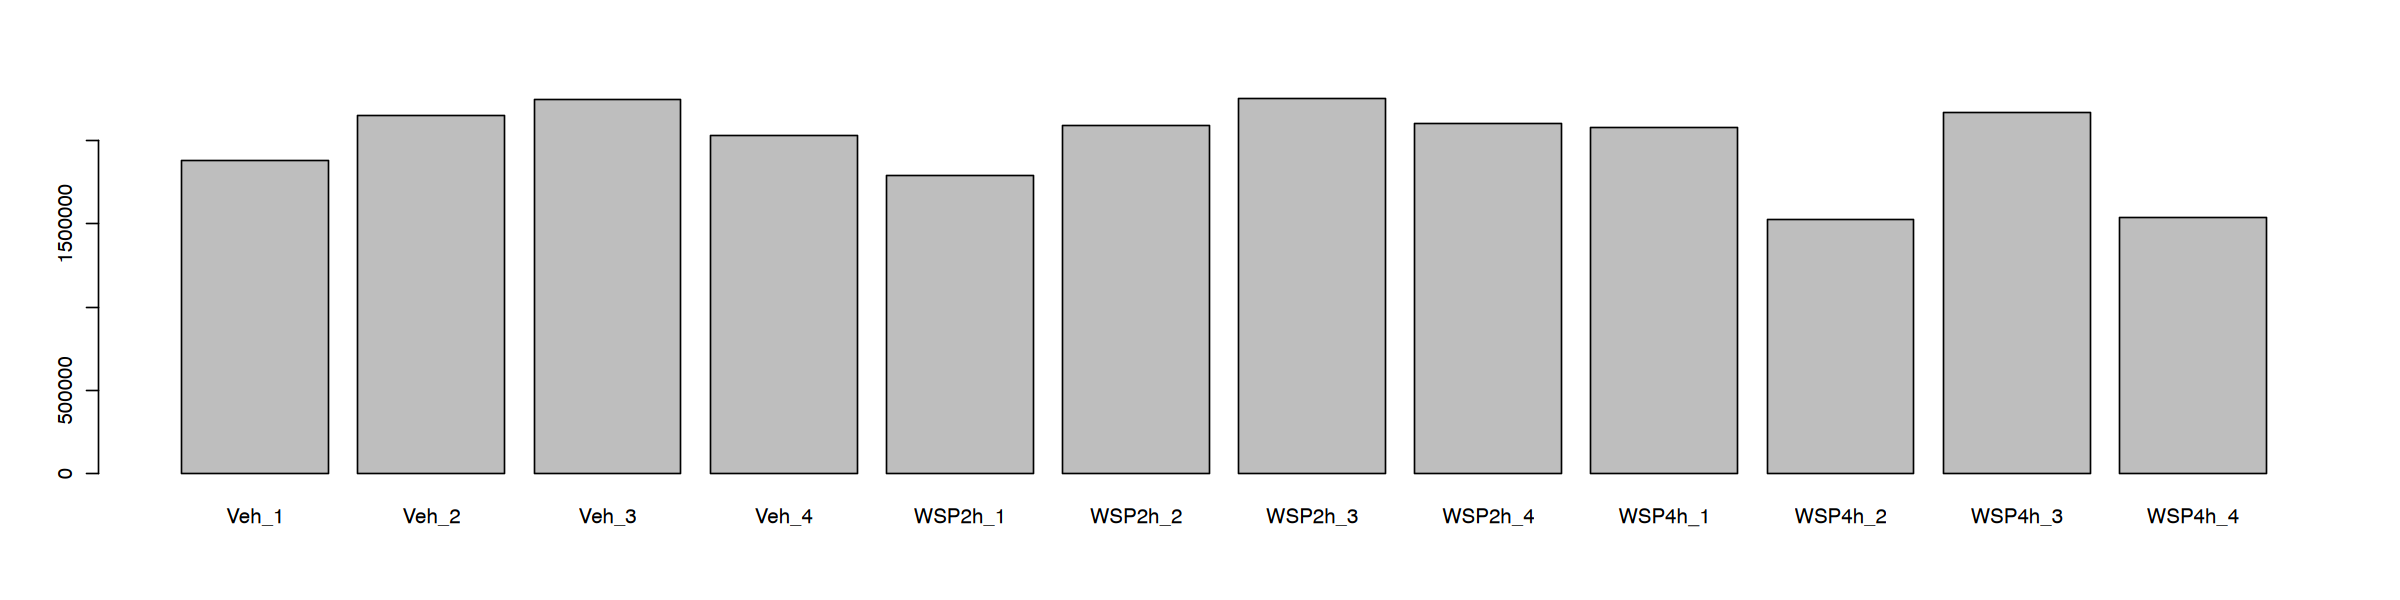

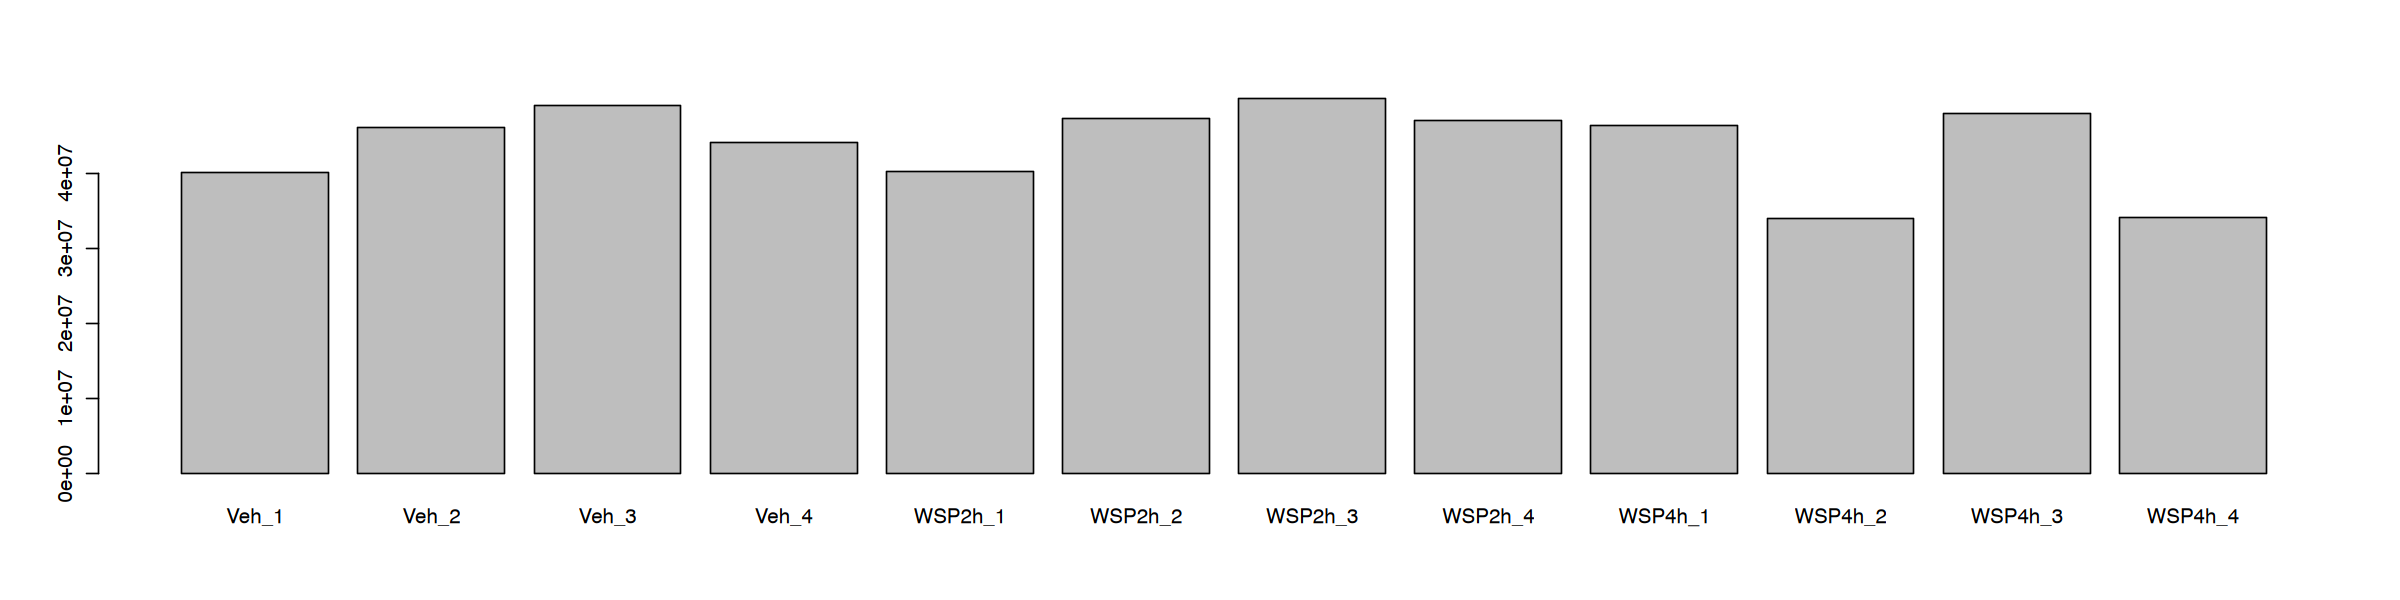

In [11]:
# check that the housekeeping genes are there
options(repr.plot.height=5, repr.plot.width=20)
hk_genes <- c(
  # Ribosomal genes (RPL and RPS families)
  "RPL3", "RPL4", "RPL5", "RPL6", "RPL7", "RPL8", "RPL9", "RPL10", "RPL10A", 
  "RPL11", "RPL12", "RPL13", "RPL13A", "RPL14", "RPL15", "RPL17", "RPL18", 
  "RPL18A", "RPL19", "RPL21", "RPL22", "RPL23", "RPL23A", "RPL24", "RPL26", 
  "RPL27", "RPL27A", "RPL28", "RPL29", "RPL30", "RPL31", "RPL32", "RPL34", 
  "RPL35", "RPL35A", "RPL36", "RPL36A", "RPL37", "RPL37A", "RPL38", "RPL39", 
  "RPS3", "RPS4X", "RPS4Y1", "RPS5", "RPS6", "RPS7", "RPS8", "RPS9", "RPS10", 
  "RPS11", "RPS12", "RPS13", "RPS14", "RPS15", "RPS15A", "RPS16", "RPS17", 
  "RPS18", "RPS19", "RPS20", "RPS21", "RPS23", "RPS24", "RPS25", "RPS26", 
  "RPS27", "RPS27A", "RPS28", "RPS29",

  # Translation factors (EEF, EIF, and GTPase families)
  "EEF1A1", "EEF1A2", "EEF1B2", "EEF1D", "EEF1G", "EEF2", "EIF1", "EIF2S1", 
  "EIF2S2", "EIF2S3", "EIF3A", "EIF3B", "EIF3C", "EIF3D", "EIF3E", "EIF3F", 
  "EIF3G", "EIF3H", "EIF3I", "EIF3J", "EIF3K", "EIF3L", "EIF3M", "EIF4A1", 
  "EIF4A2", "EIF4A3", "EIF4B", "EIF4E", "EIF4E1B", "EIF4E2", "EIF4E3", "EIF4G1", 
  "EIF4G2", "EIF4G3", "EIF5", "EIF5A", "EIF5B",

  # Transcription polymerase genes (RNA Polymerases)
  "POLR1A", "POLR1B", "POLR1C", "POLR1D", "POLR1E", "POLR2A", "POLR2B", 
  "POLR2C", "POLR2D", "POLR2E", "POLR2F", "POLR2G", "POLR2H", "POLR2I", 
  "POLR2J", "POLR2K", "POLR2L", "POLR3A", "POLR3B", "POLR3C", "POLR3D", 
  "POLR3E", "POLR3F", "POLR3G", "POLR3GL", "POLR3H"
)
length(hk_genes)
#length(intersect(gene_filt_counts$Gene, hk_genes))
gene_hk_counts <- gene_counts[gene_counts$Geneid %in% hk_genes,]
dim(gene_hk_counts)
#gene_hk_counts
barplot(colSums(gene_hk_counts[,7:ncol(gene_hk_counts)]))
barplot(colSums(gene_counts[,7:ncol(gene_hk_counts)]))

In [12]:
# get matrix formats
gene_counts_matrix <- as.matrix(gene_counts[, 7:ncol(gene_counts)])
rownames(gene_counts_matrix) <- gene_counts$Geneid
gene_counts_matrix[1:2,]
dim(gene_counts_matrix)
gene_counts <- gene_counts_matrix


gene_hk_counts <- gene_counts[intersect(hk_genes, rownames(gene_counts)),]
dim(gene_hk_counts)

,Veh_1,Veh_2,Veh_3,Veh_4,WSP2h_1,WSP2h_2,WSP2h_3,WSP2h_4,WSP4h_1,WSP4h_2,WSP4h_3,WSP4h_4
DDX11L1,0,0,0,1,0,0,0,2,0,0,0,0
WASH7P,101,120,121,125,96,168,137,133,154,115,144,100


[1] 28889    12

[1] 133  12

## 2. Design & PCA

In [13]:
design <- data.table("Name"=c("Veh_1", "Veh_2", "Veh_3", "Veh_4", 
						   "WSP2h_1", "WSP2h_2", "WSP2h_3", "WSP2h_4",
						   "WSP4h_1", "WSP4h_2", "WSP4h_3", "WSP4h_4"), 
                    "Replicate"=c("1", "2", "3", "4", "1", "2", "3", "4", "1", "2", "3", "4"), 
                    "Treatment"=c(rep("Veh", 4),rep("WSP2h", 4), rep("WSP4h", 4) ))
design$Replicate <- as.factor(design$Replicate)
design$Treatment <- as.factor(design$Treatment)
design


Name,Replicate,Treatment
<chr>,<fct>,<fct>
Veh_1,1,Veh
Veh_2,2,Veh
Veh_3,3,Veh
Veh_4,4,Veh
WSP2h_1,1,WSP2h
WSP2h_2,2,WSP2h
WSP2h_3,3,WSP2h
WSP2h_4,4,WSP2h
WSP4h_1,1,WSP4h


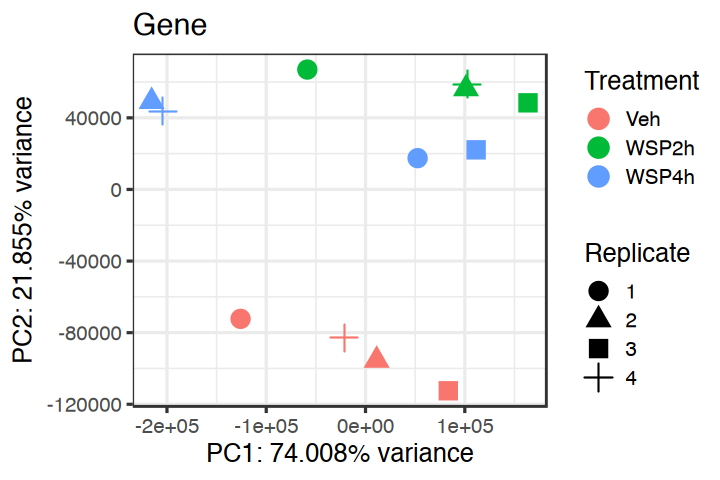

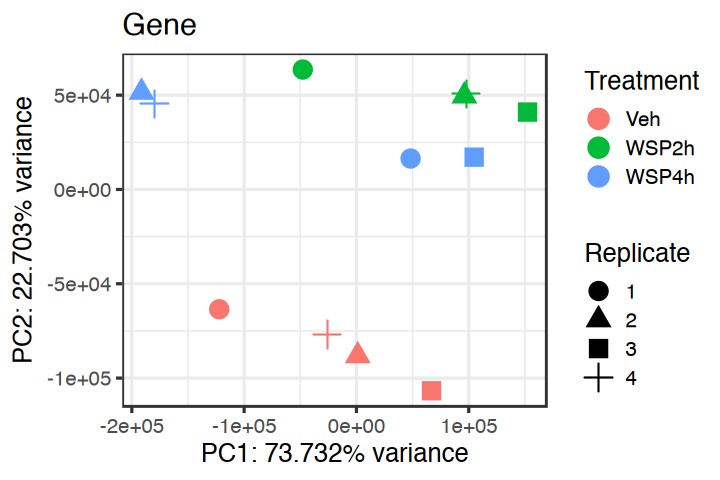

In [17]:
## Some functions for initial comparison to assess batch effects
plotPCA_hope_meta <- function(counts, metadata, ntop=500, Treat=TRUE) {
    rv <- rowVars(counts)
    length(rv) == nrow(counts)
    select <- order(rv, decreasing = TRUE)[seq_len(min(ntop,  length(rv)))]
    pca <- prcomp(t(counts[select, ]))
      percentVar <- pca$sdev^2/sum(pca$sdev^2)
    if (Treat == TRUE) {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Treatment, shape=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    } else {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    }
  
}

options(repr.plot.height = 4, repr.plot.width = 6)
plotPCA_hope_meta(gene_counts, metadata=design, ntop=500) + ggtitle(paste0("Gene"))
plotPCA_hope_meta(gene_counts, metadata=design, ntop=100) + ggtitle(paste0("Gene"))


## 

## 3. Run DESeq2

In [19]:
# get the DESeq objects
dds_gene <- DESeqDataSetFromMatrix(countData = gene_counts, colData = design, design = ~ Treatment)
dss_hk <- DESeqDataSetFromMatrix(countData = gene_hk_counts, colData = design, design = ~ Treatment)

dds_gene$Treatment <- relevel(dds_gene$Treatment, ref = "Veh")
dss_hk$Treatment <- relevel(dss_hk$Treatment, ref = "Veh")

### 3A. Size Factors

[1] 133

[1] 133

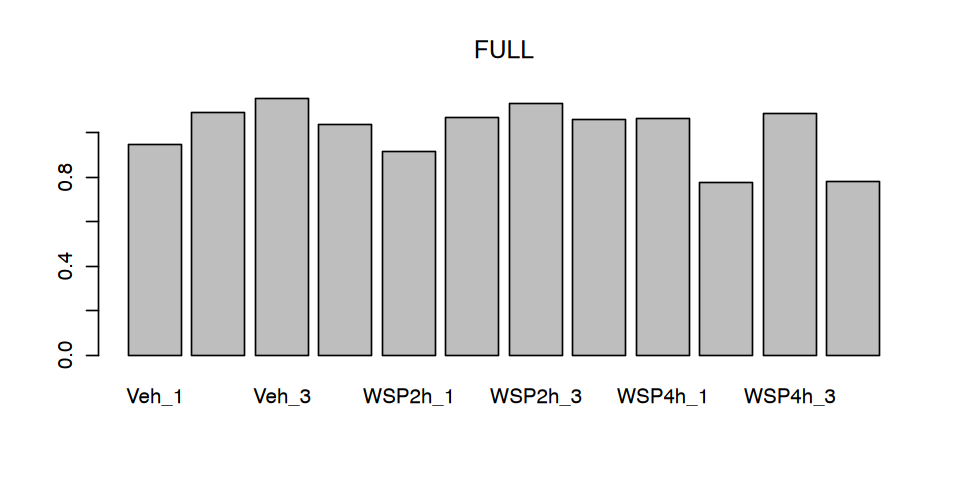

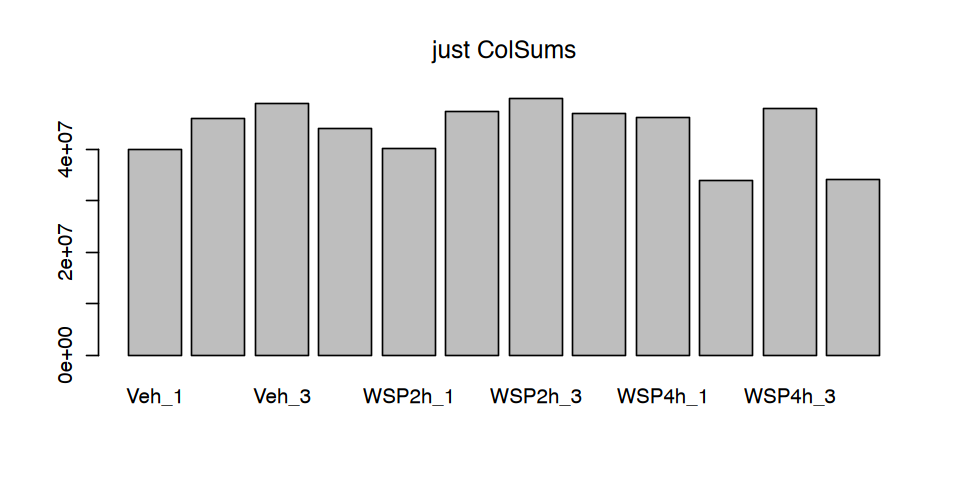

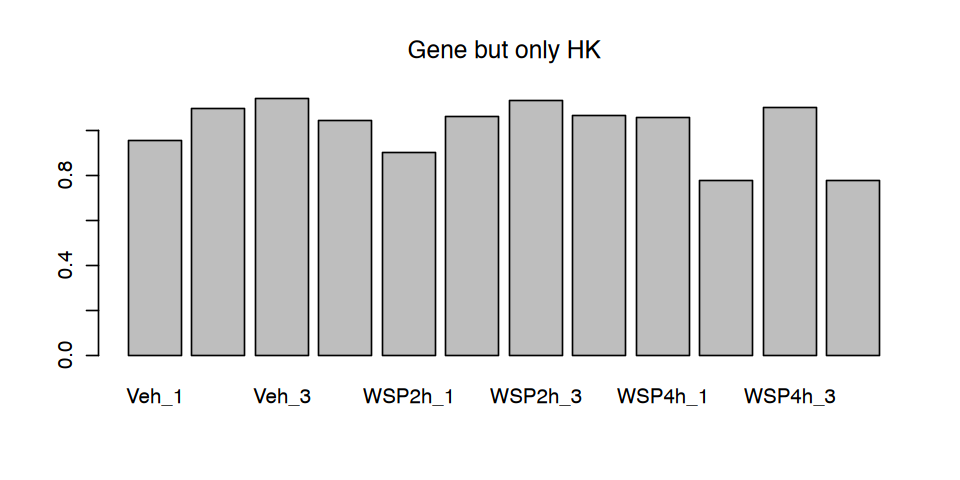

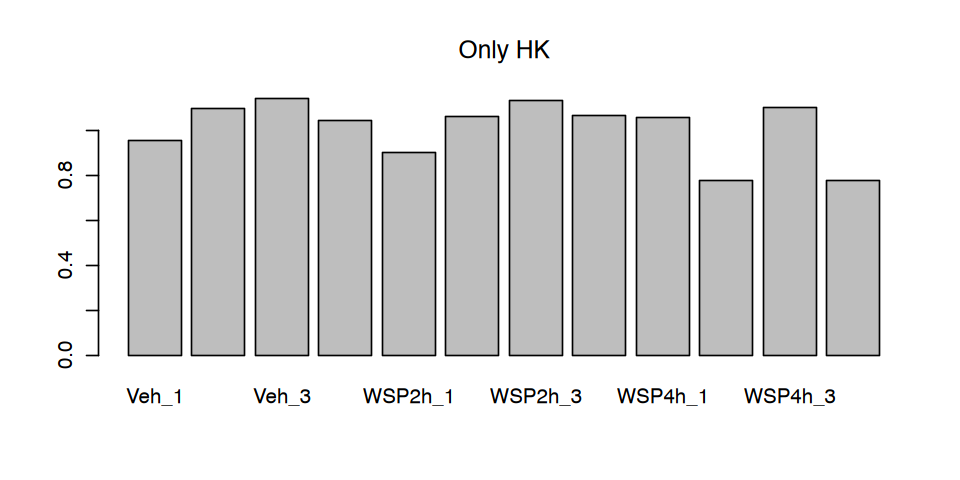

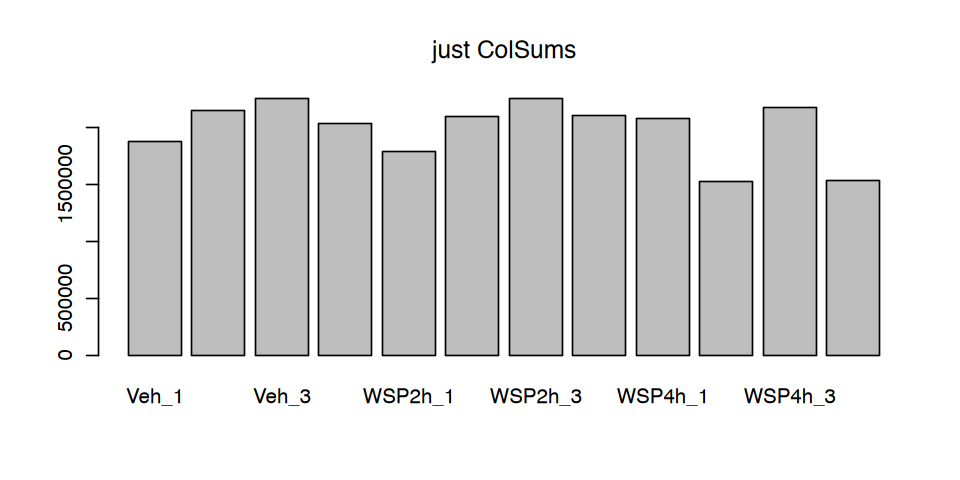

In [21]:
## Ratio
options(repr.plot.width=16)
# get just the genes for normalization
isControl <- which(rownames(dds_gene) %in% hk_genes)
length(hk_genes)
length(intersect(rownames(dds_gene), hk_genes))
dds_gene_test_FULL = estimateSizeFactors(dds_gene)
dds_gene_test_hk = estimateSizeFactors(dds_gene, controlGenes=isControl)
dds_gene_test_hkonly = estimateSizeFactors(dss_hk)
# test to see how different it would be without the control genes
options(repr.plot.height=4, repr.plot.width=8)
barplot(sizeFactors(dds_gene_test_FULL), main="FULL")
barplot(colSums(gene_counts), main="just ColSums")

barplot(sizeFactors(dds_gene_test_hk), main="Gene but only HK")
barplot(sizeFactors(dds_gene_test_hkonly), main="Only HK")
barplot(colSums(gene_hk_counts), main="just ColSums")

In [22]:
# Exact calculation of size factors doesn't matter too much so use HOUSEKEEPING GENES
sfs <- sizeFactors(dds_gene_test_hk)
sizeFactors(dds_gene) <- sfs

using ntop=500 top features by variance

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information.
i The deprecated feature was likely used in the DESeq2 package.
  Please report the issue to the authors."


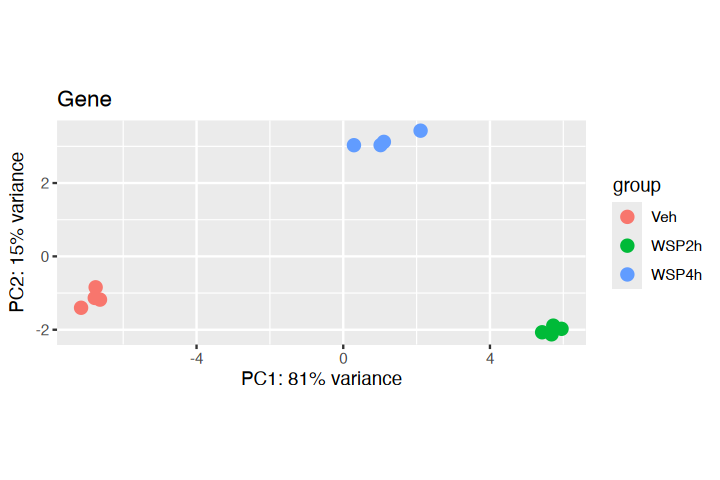

In [24]:
# plot PCA with with DESeq2 size factors
options(repr.plot.width=6, repr.plot.height=4)
# Ratio
vsd <- vst(dds_gene, blind = FALSE)
plotPCA(vsd, intgroup = "Treatment") + ggtitle(paste0("Gene"))

In [25]:
# save normalized counts
count_df = as.data.frame(counts(dds_gene, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/WSP_RNAseq_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)
gc()

,Veh_1,Veh_2,Veh_3,Veh_4,WSP2h_1,WSP2h_2,WSP2h_3,WSP2h_4,WSP4h_1,WSP4h_2,WSP4h_3,WSP4h_4,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DDX11L1,0.000,0.000,0.0000,0.9599782,0.000,0.0000,0.0000,1.874102,0.0000,0.0000,0.0000,0.0000,DDX11L1
WASH7P,105.856,109.665,106.0417,119.9972757,106.535,158.4451,120.8592,124.627788,145.5898,148.4347,130.7618,128.7125,WASH7P


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,8863688,473.4,15508980,828.3,NA,15508980,828.3
Vcells,17448906,133.2,31039775,236.9,16384,31039140,236.9


### 3B. Estimate Dispersion and Run Significance Tests

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



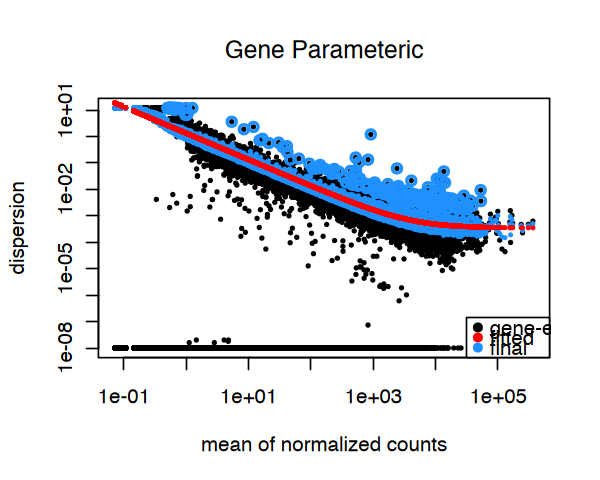

In [26]:
## Ratio Normalization (parameteric is default)
dds_gene = estimateDispersions(dds_gene, fitType="parametric")
options(repr.plot.height=4, repr.plot.width=5)
plotDispEsts(dds_gene, main= "Gene Parameteric")

In [27]:
dds_gene = nbinomWaldTest(dds_gene)

### 3C. Get Results

In [28]:
binwidth_use=0.05
# Set your thresholds
padj_threshold <- 0.05
log2fc_threshold <- 0

In [29]:
# Get the significance comparisons ready
Up_Sig_genes = list("P4h_vs_Veh"=c(), "P2h_vs_Veh"=c(), "P4h_vs_P2h"=c())
Down_Sig_genes = list("P4h_vs_Veh"=c(), "P2h_vs_Veh"=c(), "P4h_vs_P2h"=c())
All_Sig_genes = list("P4h_vs_Veh_up"=c(), "P2h_vs_Veh_up"=c(), "P4h_vs_P2h_up"=c(), 
                     "P4h_vs_Veh_down"=c(), "P2h_vs_Veh_down"=c(), "P4h_vs_P2h_down"=c())

[1] "WSP2hr vs Veh"

out of 24479 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2652, 11%
LFC < 0 (down)     : 1868, 7.6%
outliers [1]       : 3, 0.012%
low counts [2]     : 7522, 31%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
"Removed 4413 rows containing non-finite outside the scale range (`stat_bin()`)."


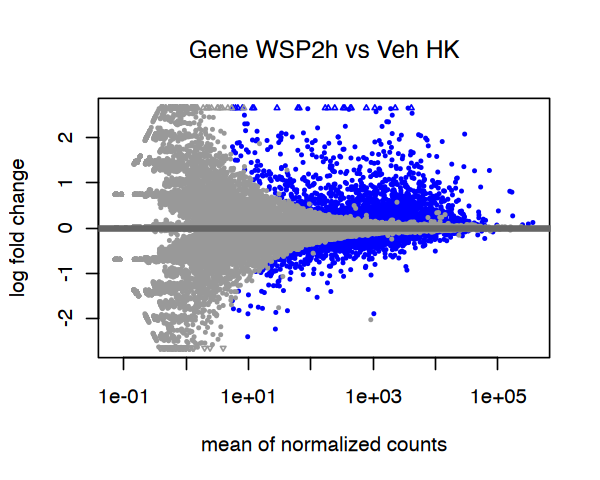

[1] 2652

[1] 1868

Warning message:
"Removed 4410 rows containing missing values or values outside the scale range
(`geom_point()`)."


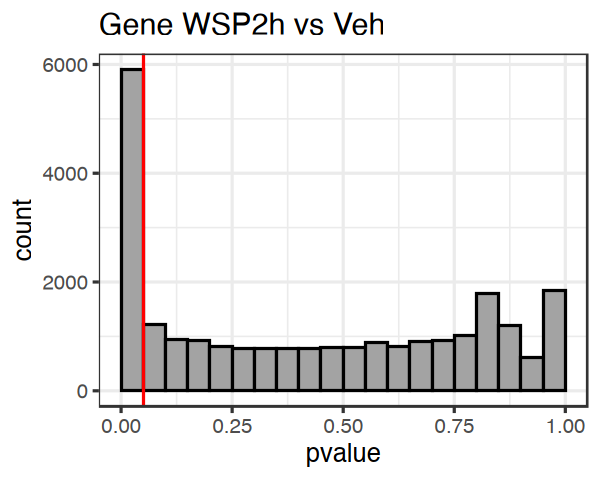

[1] "WSP4h vs Veh"

out of 24479 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 2369, 9.7%
LFC < 0 (down)     : 1471, 6%
outliers [1]       : 3, 0.012%
low counts [2]     : 8931, 36%
(mean count < 12)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



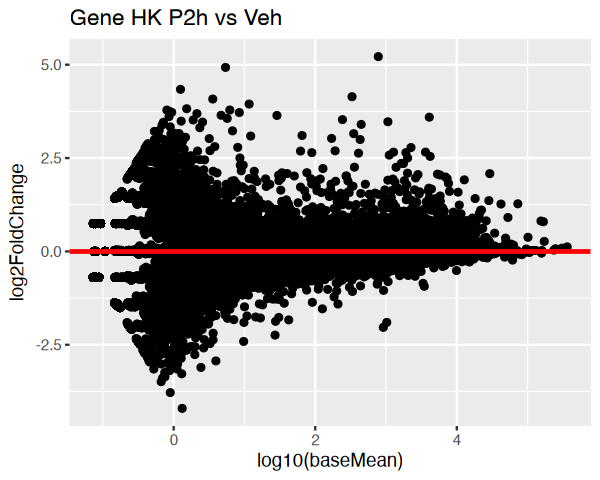

Warning message:
"Removed 4413 rows containing non-finite outside the scale range (`stat_bin()`)."


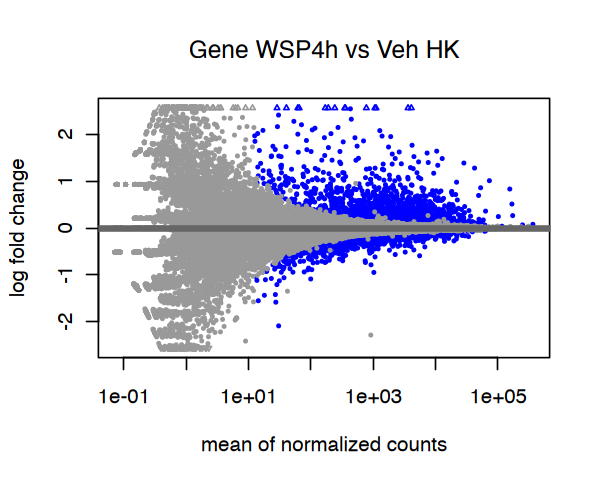

[1] 2369

[1] 1471

Warning message:
"Removed 4410 rows containing missing values or values outside the scale range
(`geom_point()`)."


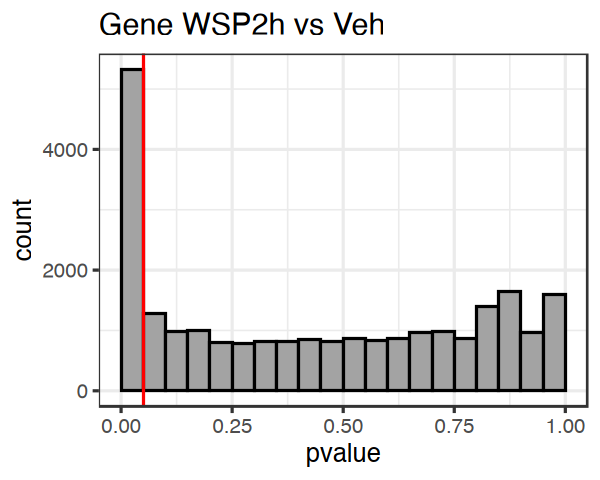

[1] "WSP4h vs WSP2h"

out of 24479 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1765, 7.2%
LFC < 0 (down)     : 2001, 8.2%
outliers [1]       : 3, 0.012%
low counts [2]     : 9400, 38%
(mean count < 17)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



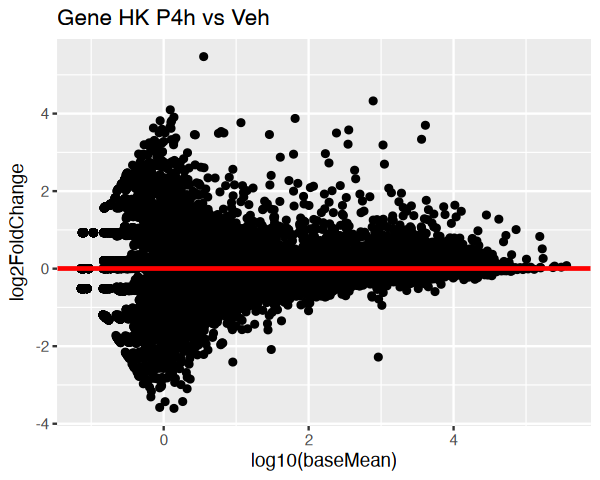

Warning message:
"Removed 4413 rows containing non-finite outside the scale range (`stat_bin()`)."


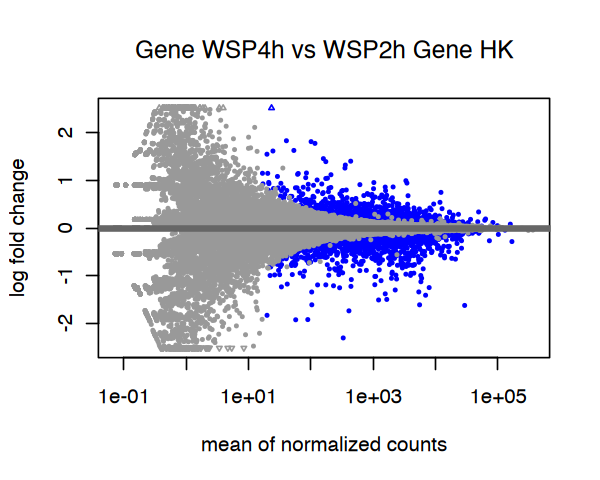

[1] 1765

[1] 2001

Warning message:
"Removed 4410 rows containing missing values or values outside the scale range
(`geom_point()`)."


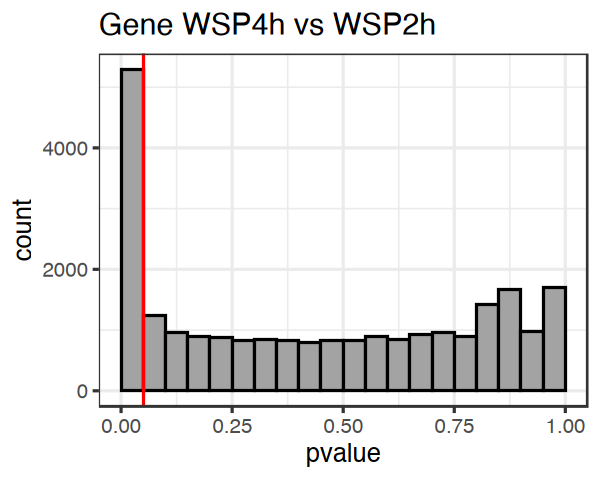

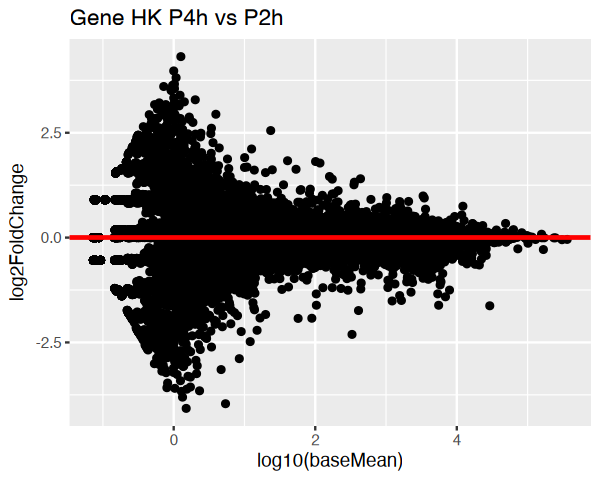

In [32]:
# Gene Results
padj_threshold=0.05
print("WSP2hr vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene, contrast= c("Treatment", "WSP2h", "Veh"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP2h vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP2h vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P2h_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P2h_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P2h_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P2h_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("Gene HK P2h vs Veh")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_RNAseq_WSP2h_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

print("WSP4h vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene, contrast= c("Treatment", "WSP4h", "Veh"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP4h vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP2h vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P4h_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P4h_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P4h_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P4h_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("Gene HK P4h vs Veh")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_RNAseq_WSP4h_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

print("WSP4h vs WSP2h")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene, contrast= c("Treatment", "WSP4h", "WSP2h"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP4h vs WSP2h Gene HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP4h vs WSP2h")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P4h_vs_P2h"]] = up_sig_genes
All_Sig_genes[["P4h_vs_P2h_up"]] = up_sig_genes
Down_Sig_genes[["P4h_vs_P2h"]] = down_sig_genes
All_Sig_genes[["P4h_vs_P2h_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("Gene HK P4h vs P2h")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_RNAseq_WSP4h_vs_WSP2h_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

## 4. GO Analysis

In [33]:
run_go_analysis <- function(gene_symbols) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

In [ ]:
## EARLY and Temporary
early_rise_genes = setdiff(intersect(Up_Sig_genes[["P2h_vs_Veh"]], Down_Sig_genes[["P4h_vs_P2h"]]), 
                           union(Up_Sig_genes[["P4h_vs_Veh"]], Down_Sig_genes[["P4h_vs_Veh"]]))
length(early_rise_genes)
go_early_rise = run_go_analysis(early_rise_genes)
early_fall_genes = setdiff(intersect(Down_Sig_genes[["P2h_vs_Veh"]], Up_Sig_genes[["P4h_vs_P2h"]]), 
                           union(Up_Sig_genes[["P4h_vs_Veh"]], Down_Sig_genes[["P4h_vs_Veh"]]))
length(early_fall_genes)
go_early_fall = run_go_analysis(early_fall_genes)

[1] 587

[1] 639

In [35]:
## Early and stays (plateaus)
early_plat_up = setdiff(intersect(Up_Sig_genes[["P4h_vs_Veh"]], Up_Sig_genes[["P2h_vs_Veh"]]), 
                    union(Up_Sig_genes[["P4h_vs_P2h"]], Down_Sig_genes[["P4h_vs_P2h"]]))
length(early_plat_up)
go_early_plat_up = run_go_analysis(early_plat_up)
early_plat_down = setdiff(intersect(Down_Sig_genes[["P4h_vs_Veh"]], Down_Sig_genes[["P2h_vs_Veh"]]), 
                    union(Up_Sig_genes[["P4h_vs_P2h"]], Down_Sig_genes[["P4h_vs_P2h"]]))
length(early_plat_down)
go_early_plat_down = run_go_analysis(early_plat_down)

[1] 845

[1] 455

In [36]:
## LATE
late_up = setdiff(intersect(Up_Sig_genes[["P4h_vs_Veh"]], Up_Sig_genes[["P4h_vs_P2h"]]), 
                    union(Up_Sig_genes[["P2h_vs_Veh"]], Down_Sig_genes[["P2h_vs_Veh"]]))
length(late_up)
go_late_up = run_go_analysis(late_up)
late_down = setdiff(intersect(Down_Sig_genes[["P4h_vs_Veh"]], Down_Sig_genes[["P4h_vs_P2h"]]), 
                    union(Up_Sig_genes[["P2h_vs_Veh"]], Down_Sig_genes[["P2h_vs_Veh"]]))
length(late_down)
go_late_down = run_go_analysis(late_down)

[1] 440

[1] 382

In [37]:
go_early_both = run_go_analysis(union(early_rise_genes, early_fall_genes))
go_early_plat_both = run_go_analysis(union(early_plat_up, early_plat_down))
go_late_both = run_go_analysis(union(late_up, late_down))

#### GO Term Numbers
* Early Rise: 587 genes, 40 enriched terms
* Early Fall: 639 genes, 5 enriched terms
* Late Up: 440 genes, 1 enriched terms
* Late Down: 382 genes, 105 enriched terms
* Early Plateau Up: 845 genes, 181 enriched terms
* Early Plateau Down: 455 genes, 49 enriched terms

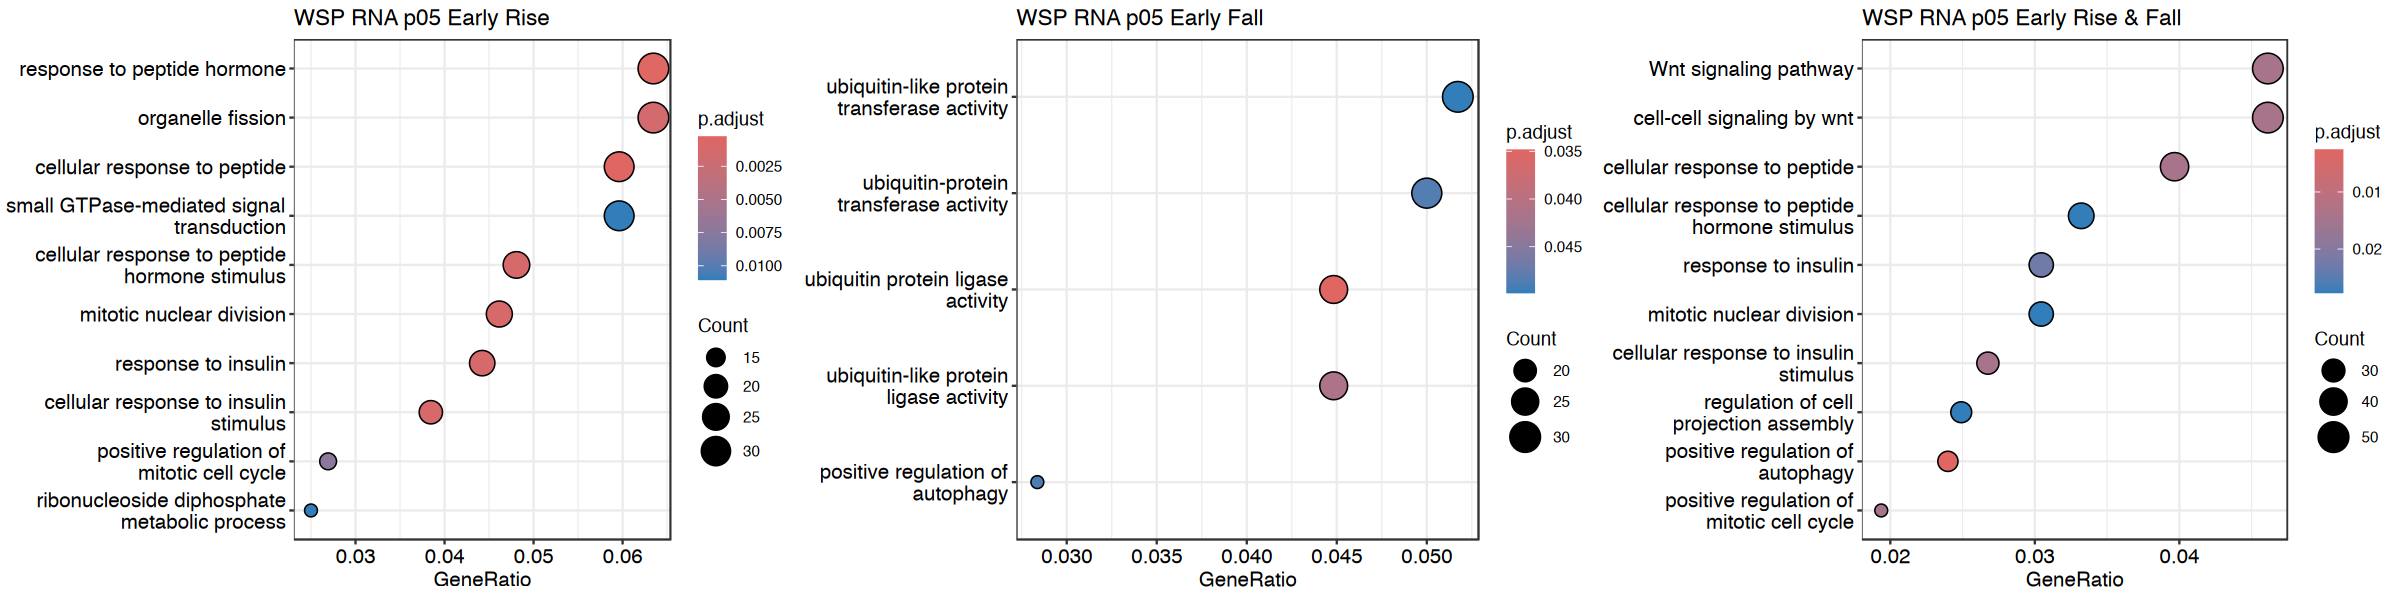

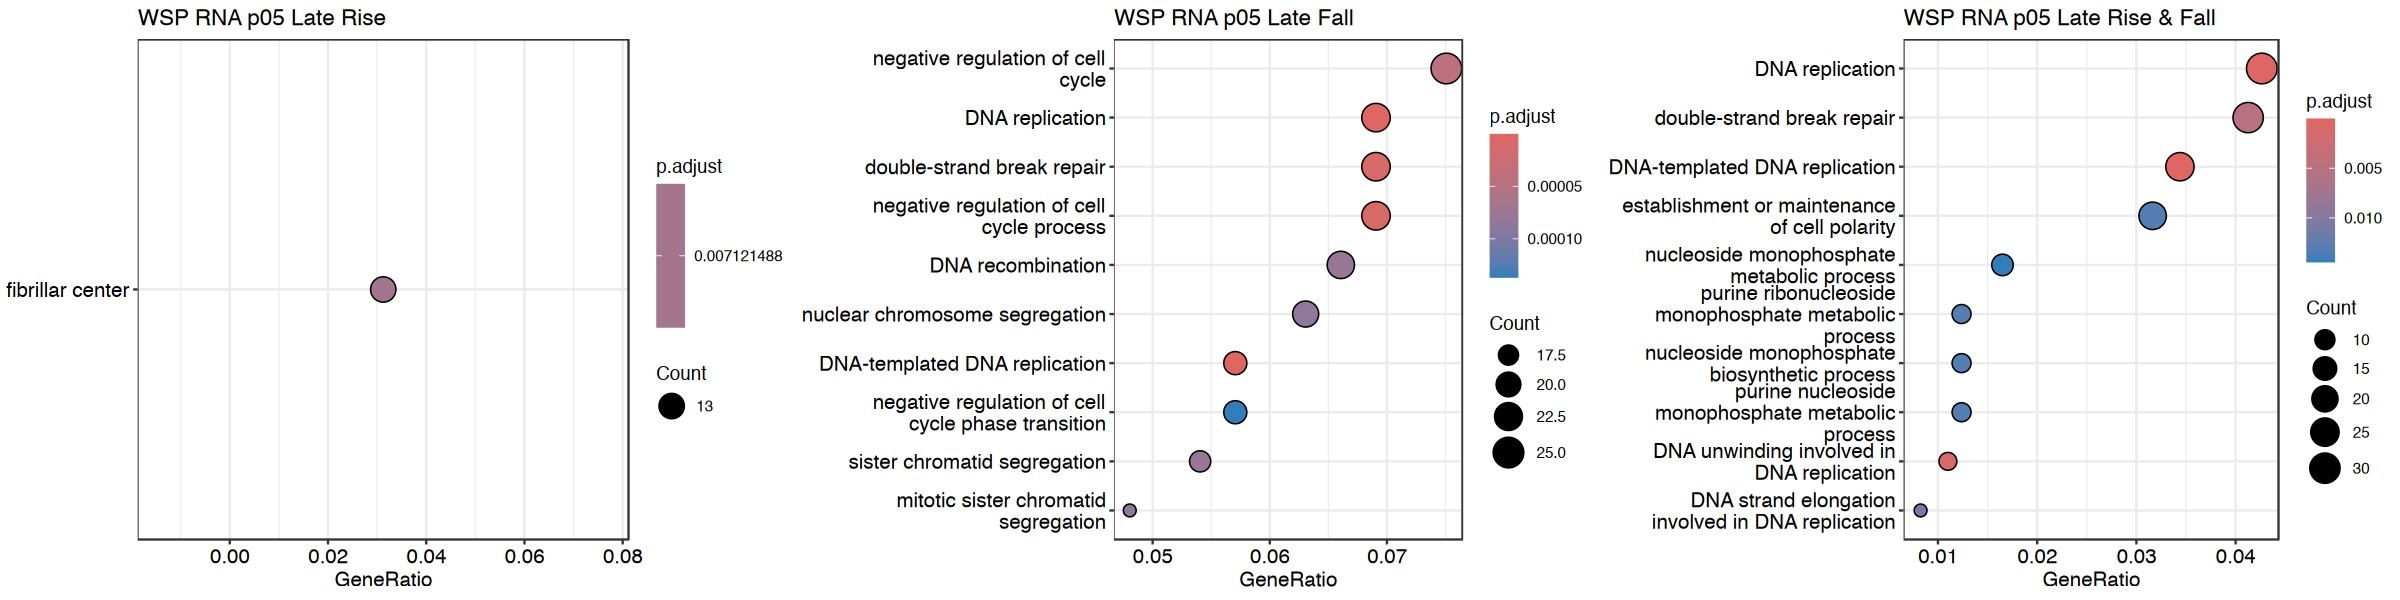

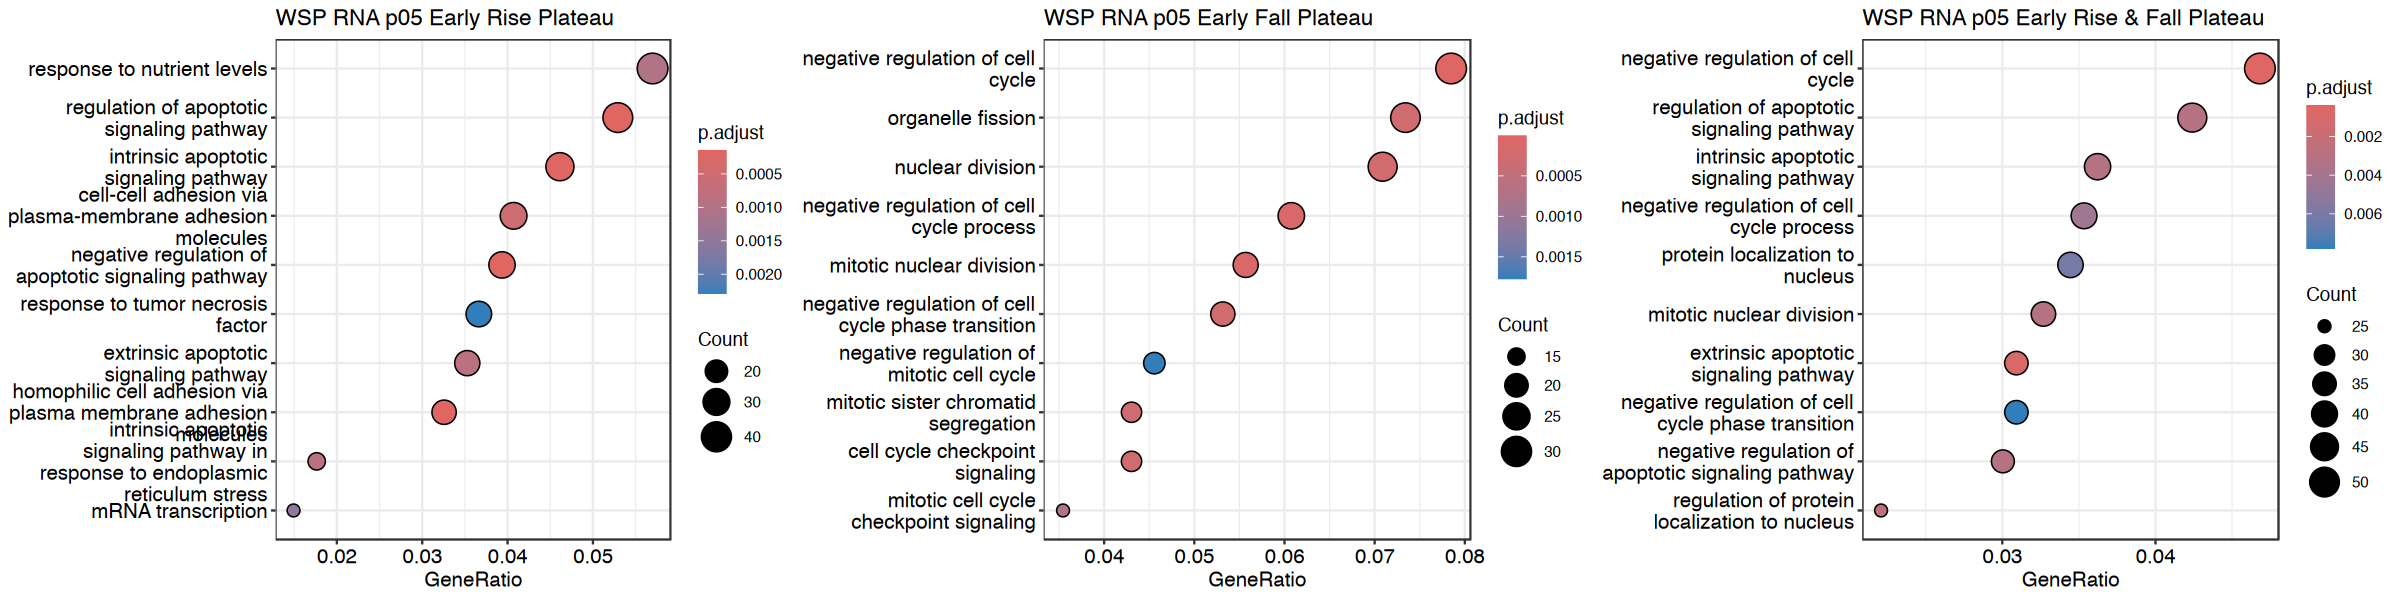

In [38]:
options(repr.plot.height=5, repr.plot.width=20)
pert="WSP RNA p05"
p1 <- dotplot(go_early_rise, showCategory = 10, title=paste(pert,  "Early Rise"))
p2 <- dotplot(go_early_fall, showCategory = 10, title=paste(pert,  "Early Fall"))
p3 <- dotplot(go_early_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall"))
grid.arrange(p1, p2, p3, ncol = 3)
# options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_late_up, showCategory = 10, title=paste(pert,  "Late Rise"))
p2 <- dotplot(go_late_down, showCategory = 10, title=paste(pert,  "Late Fall"))
p3 <- dotplot(go_late_both, showCategory = 10, title=paste(pert,  "Late Rise & Fall"))
grid.arrange(p1, p2, p3, ncol = 3)
options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_early_plat_up, showCategory = 10, title=paste(pert,  "Early Rise Plateau"))
p2 <- dotplot(go_early_plat_down, showCategory = 10, title=paste(pert,  "Early Fall Plateau"))
p3 <- dotplot(go_early_plat_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall Plateau"))
grid.arrange(p1, p2, p3, ncol = 3)

In [49]:
pert="WSP_RNAseq"
write.table(go_early_rise, paste0("../results/GO/GO_EarlyRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_fall, paste0("../results/GO/GO_EarlyFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_late_up, paste0("../results/GO/GO_LateRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_late_down, paste0("../results/GO/GO_LateFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_early_plat_up, paste0("../results/GO/GO_EarlyRisePlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_plat_down, paste0("../results/GO/GO_EarlyFallPlat", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)

In [50]:
saveRDS(All_Sig_genes, paste0(results_dir, "WSPRNAseq_siggenes_DESeq2_GeneHK.rds"))